In [1]:
#!pip install segmentation-models-pytorch
#!pip install -U git+https://github.com/albumentations-team/albumentations
#!pip install --upgrade opencv-contrib-python

In [2]:
!nvidia-smi

Thu Jun  6 07:18:09 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.171.04             Driver Version: 535.171.04   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 3090        Off | 00000000:01:00.0 Off |                  N/A |
|  0%   45C    P8              23W / 370W |      1MiB / 24576MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

## Dataset

In [3]:
!git clone https://github.com/parth1620/Human-Segmentation-Dataset-master.git

fatal: destination path 'Human-Segmentation-Dataset-master' already exists and is not an empty directory.


In [4]:
#import sys
#sys.path.append('Human-Segmentation-Dataset-master')

In [5]:
import torch 
import cv2

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from tqdm import tqdm

import helper

## Task : 2 Setup Configurations


In [6]:
#CSV_FILE = 'Human-Segmentation-Dataset-master/train.csv'
CSV_FILE = 'DataFN.csv'
CSV_testFILE = 'DataTestFN.csv'
CSV_testFILE0 = 'DataTestFN0.csv'
CSV_testFILE100 = 'DataTestFN100.csv'
DATA_DIR = ''

DEVICE = 'cuda'

EPOCHS = 1000
IMAGE_SIZE = 192
BATCH_SIZE = 64
Patience = 30
ENCODER = 'timm-efficientnet-b1'
WEIGHTS = 'imagenet'

In [7]:
df = pd.read_csv(CSV_FILE)
test_df = pd.read_csv(CSV_testFILE)
test_df0 = pd.read_csv(CSV_testFILE0)
test_df100 = pd.read_csv(CSV_testFILE100)
df.head()

,images,masks
0,Dataset/train/Flair/P10_T1_100.png,Dataset/train/Mask/P10_T1_100.png
1,Dataset/train/Flair/P10_T1_101.png,Dataset/train/Mask/P10_T1_101.png
2,Dataset/train/Flair/P10_T1_102.png,Dataset/train/Mask/P10_T1_102.png
3,Dataset/train/Flair/P10_T1_103.png,Dataset/train/Mask/P10_T1_103.png
4,Dataset/train/Flair/P10_T1_104.png,Dataset/train/Mask/P10_T1_104.png


In [8]:
row = df.iloc[500]

image_path = row.images
mask_path = row.masks

image = cv2.imread(image_path)
#image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

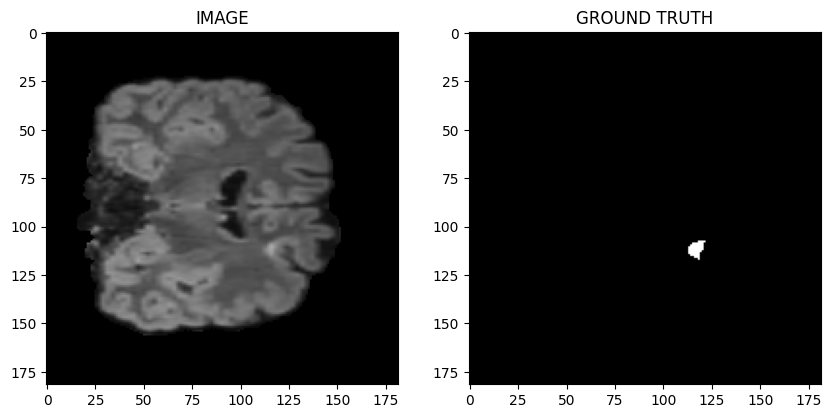

In [9]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
        
ax1.set_title('IMAGE')
ax1.imshow(image)

ax2.set_title('GROUND TRUTH')
ax2.imshow(mask,cmap = 'gray')

In [10]:
train_df, valid_df = train_test_split(df, test_size=0.2, random_state=42)

## Task 3 : Augmentation Functions


In [11]:
import albumentations as A

def get_train_augs():
  return A.Compose([
      A.HorizontalFlip(p=0.5),
      A.VerticalFlip(p=0.5)
  ])
def get_valid_augs():
  return A.Compose([
    ])

## Task 4 : Create Custom Dataset


In [12]:
from torch.utils.data import Dataset

class SegmentationDataset(Dataset):
  def __init__(self,df, augmentations):
    self.df=df
    self.augmentations = augmentations 
  def __len__(self):
    return len(self.df)
  def __getitem__(self ,idx):
    row = self.df.iloc[idx]
    image_path = row.images
    mask_path = row.masks

    #print('image path: ', image_path)
    #print('mask path: ', mask_path)
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE), interpolation = cv2.INTER_CUBIC)

    mask = cv2.imread(mask_path , cv2.IMREAD_GRAYSCALE) #(h,w,c)
    #print('mask 0 size: ', mask.shape)
    mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE), interpolation = cv2.INTER_CUBIC)
    mask =np.expand_dims(mask ,axis=-1)
    #print('image size: ', image.shape)
    #print('mask size: ', mask.shape)

    if self.augmentations :
      data =self.augmentations(image = image , mask = mask)
      image = data['image']
      mask = data ['mask']

    #(h,w,c) -> (c,h,w)
    image = np.transpose(image ,(2,0,1)).astype(np.float32)
    mask = np.transpose(mask ,(2,0,1)).astype(np.float32)

    image = torch.Tensor(image)/255.0
    mask = torch.round(torch.Tensor(mask)/255.0)

    return image,mask

In [13]:
trainset = SegmentationDataset(train_df,get_train_augs())
validset = SegmentationDataset(valid_df,get_valid_augs())
testset = SegmentationDataset(test_df,get_valid_augs())
testset0 = SegmentationDataset(test_df0,get_valid_augs())
testset100 = SegmentationDataset(test_df100,get_valid_augs())


In [14]:
print(f"Size of Trainset : {len(trainset)}")
print(f"Size of Validset : {len(validset)}")

Size of Trainset : 8649
Size of Validset : 2163


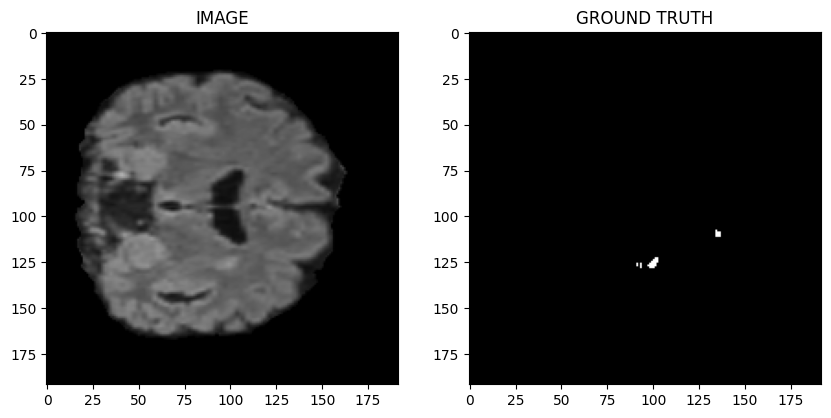

In [15]:
idx = 70
image,mask = trainset[idx]
helper.show_image(image,mask)


## Task 5 : Load dataset into batches


In [16]:
from torch.utils.data import DataLoader

trainloader = DataLoader(trainset , batch_size =BATCH_SIZE , shuffle =True )
validloader = DataLoader(validset , batch_size =BATCH_SIZE  )

In [17]:
print(f"total no,of batches in trainloader: {len(trainloader)}")
print(f"total no,of batches in validloader: {len(validloader)}")

total no,of batches in trainloader: 136
total no,of batches in validloader: 34


In [18]:
for image , mask in trainloader:
  break
print (f'One batch image shape: {image.shape}')
print (f'One batch image shape: {mask.shape}')

One batch image shape: torch.Size([64, 3, 192, 192])
One batch image shape: torch.Size([64, 1, 192, 192])



## Task 6 : Create Segmentation Model


In [19]:
#! pip install segmentation_models_pytorch

In [21]:

class BinaryIntersection(torch.nn.Module):
    def forward(self, pred, target):
        intersection = (pred * target).sum()
        return  intersection

class BinaryUnion(torch.nn.Module):
    def forward(self, pred, target):
        intersection = (pred * target).sum()
        union = pred.sum() + target.sum() - intersection
        #print('predict: ', pred.sum())
        #print('target : ', target.sum())
        
        return  union

A , B = 0 , 0
class BinaryJaccardLoss(torch.nn.Module):
    def forward(self, pred, target):
       if (pred.sum() ==0) and (target.sum() == 0):
            jaccard_index = 1
       else:        
            intersection = (pred * target).sum() + A
            union = pred.sum() + target.sum() - intersection + B
            jaccard_index = 1 - intersection / (union)
       return  jaccard_index


In [20]:
from torch import nn 
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss
import timm


In [22]:

class CustomUnet(smp.Unet):
    def __init__(self, encoder_name, encoder_weights, in_channels, classes, activation):
        super().__init__(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=in_channels,
            classes=classes,
            activation=activation
        )
        self.encoder = timm.create_model(encoder_name, pretrained=True, in_chans=in_channels)

# Usage
ENCODER = 'vit_base_patch16_224'
WEIGHTS = 'imagenet'
#model = CustomUnet(
#    encoder_name=ENCODER,
#    encoder_weights=WEIGHTS,
#    in_channels=3,
#    classes=1,
#    activation=None)





class SegmentationModel (nn.Module):

  def __init__(self):
    super (SegmentationModel , self).__init__()
    
    self.arc = CustomUnet(
    encoder_name=ENCODER,
    encoder_weights=WEIGHTS,
    in_channels=3,
    classes=1,
    activation=None)

    
  def forward (self ,images ,masks = None):
    result = self.arc(images)
    result = torch.sigmoid (result)
      
    if masks != None :
      loss1 = BinaryJaccardLoss()(result , masks)
      return result , loss1
    return result

In [23]:
model = SegmentationModel()
model.to(DEVICE)

SegmentationModel(
  (arc): Unet(
    (encoder): EfficientNetEncoder(
      (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNormAct2d(
        32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): Swish()
      )
      (blocks): Sequential(
        (0): Sequential(
          (0): DepthwiseSeparableConv(
            (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (bn1): BatchNormAct2d(
              32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
              (drop): Identity()
              (act): Swish()
            )
            (se): SqueezeExcite(
              (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (act1): Swish()
              (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (gate): Sigmoid()
            )
           


## Task 7 : Create Train and Validation Function


In [24]:
def train_fn (data_loader , model , optimizer):
  model.train()
  total_loss =0.0

  for images, masks in tqdm(data_loader) :

    images = images.to(DEVICE)
    masks = masks.to(DEVICE)

    optimizer.zero_grad()
    logits , loss = model(images ,masks)
    loss.backward()
    optimizer.step()

    total_loss +=loss.item()

    return total_loss / len(data_loader)

In [25]:
def eval_fn (data_loader , model ):

  model.eval()
  total_loss =0.0

  with torch.no_grad():
    for images, masks in tqdm(data_loader) :

      images = images.to(DEVICE)
      masks = masks.to(DEVICE)

      logits , loss = model(images ,masks)

      total_loss +=loss.item()

  return total_loss / len(data_loader)


## Task 8 : Train Model


In [26]:
class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        #torch.save(model.state_dict(), 'checkpoint.pt')
        self.val_loss_min = val_loss

early_stopping = EarlyStopping(patience=Patience, verbose=True)


In [27]:
import GPUtil
from torch.optim.lr_scheduler import ReduceLROnPlateau

LR = 0.01
LR_Reduce_freq = 20

optimizer = torch.optim.Adam(model.parameters(),lr= LR)
#scheduler = ReduceLROnPlateau(optimizer, 'min')
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.8)


best_valid_loss = np.Inf
for i in range(EPOCHS):
    GPUtil.showUtilization()
    print('Learning rate = ', scheduler.get_last_lr()[0])
    train_loss = train_fn(trainloader , model , optimizer)
    #print('train_loss = ', train_loss)
    valid_loss = eval_fn(validloader , model  )
    #print('valid_loss = ', valid_loss)

    if valid_loss< best_valid_loss :
        torch.save(model.state_dict(), 'bestModel.pt')
        print ("SAVED")
        best_valid_loss = valid_loss
    print(f"Epoch : {i+1} train_loss :{train_loss} valid_loss :{valid_loss}" )
    
    if (i+1) % LR_Reduce_freq == 0:
        scheduler.step()
    early_stopping(valid_loss, model)

    if early_stopping.early_stop:
        print("Early stopping")
        break
    

| ID | GPU | MEM |
------------------
|  0 |  3% |  1% |
Learning rate =  0.01


  0%|          | 0/136 [00:00<?, ?it/s]/home/jupyter-ziaratban_stu4/.local/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,
100%|██████████| 34/34 [00:02<00:00, 13.42it/s]


SAVED
Epoch : 1 train_loss :0.007338834159514483 valid_loss :0.9977221962283639
Validation loss decreased (inf --> 0.997722).  Saving model ...
| ID | GPU | MEM |
------------------
|  0 | 40% | 42% |
Learning rate =  0.01


100%|██████████| 34/34 [00:02<00:00, 13.75it/s]


Epoch : 2 train_loss :0.0073244957362904265 valid_loss :0.9977223680299871
EarlyStopping counter: 1 out of 30
| ID | GPU | MEM |
------------------
|  0 | 57% | 42% |
Learning rate =  0.01


...

Epoch : 336 train_loss :0.0021463452893144943 valid_loss :0.3429441311780144
EarlyStopping counter: 28 out of 30
| ID | GPU | MEM |
------------------
|  0 | 56% | 42% |
Learning rate =  0.0002814749767106563


100%|██████████| 34/34 [00:02<00:00, 13.30it/s]


Epoch : 337 train_loss :0.002385465976069955 valid_loss :0.34294475527370677
EarlyStopping counter: 29 out of 30
| ID | GPU | MEM |
------------------
|  0 | 51% | 42% |
Learning rate =  0.0002814749767106563


100%|██████████| 34/34 [00:02<00:00, 13.22it/s]

Epoch : 338 train_loss :0.0026501075309865616 valid_loss :0.3427348732948303
EarlyStopping counter: 30 out of 30
Early stopping



## Task 9 : Inference


Jaccard = , 0.7218390703201294 ,  Intersection = 314.0 , Union = 435.0


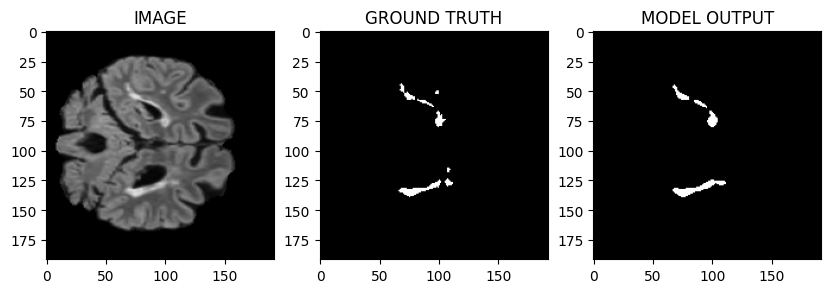

In [28]:
idx = 689
model.load_state_dict(torch. load('bestModel.pt'))
image, mask = testset[idx]
image1 = image.to(DEVICE)
mask1 = mask.to(DEVICE)
logits_mask = model (image1.unsqueeze (0)) #(C, H, W) -> (1, C, H, W)
pred_mask = logits_mask
pred_mask = (pred_mask > 0.5)*1.0
J = 1-BinaryJaccardLoss()(pred_mask, mask1)
I = BinaryIntersection()(pred_mask, mask1)
U = BinaryUnion()(pred_mask, mask1)
print(f'Jaccard = , {J} ,  Intersection = {I} , Union = {U}')


helper.show_image(image, mask, pred_mask.detach().cpu().squeeze(0))

Jaccard = , 0.0 ,  Intersection = 0.0 , Union = 1.0


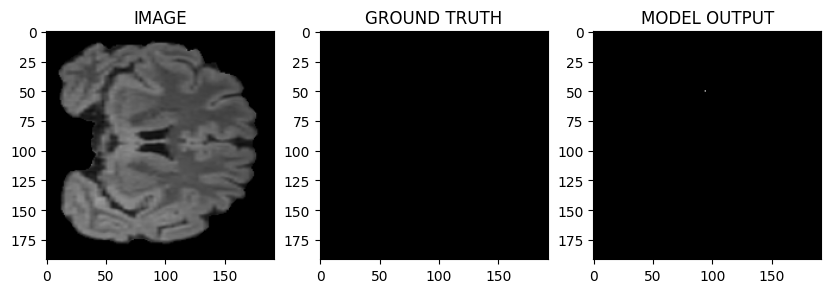

In [29]:
idx = 40
model.load_state_dict(torch. load('bestModel.pt'))
image, mask = testset[idx]
image1 = image.to(DEVICE)
mask1 = mask.to(DEVICE)
logits_mask = model (image1.unsqueeze (0)) #(C, H, W) -> (1, C, H, W)
pred_mask = logits_mask
pred_mask = (pred_mask > 0.5)*1.0
J = 1-BinaryJaccardLoss()(pred_mask, mask1)
I = BinaryIntersection()(pred_mask, mask1)
U = BinaryUnion()(pred_mask, mask1)
print(f'Jaccard = , {J} ,  Intersection = {I} , Union = {U}')


helper.show_image(image, mask, pred_mask.detach().cpu().squeeze(0))

In [30]:
J = [0]*len(validset)
I = [0]*len(validset)
U = [0]*len(validset)
for idx in range(len(validset)):
    image, mask = validset[idx]
    image = image.to(DEVICE)
    mask = mask.to(DEVICE)
    logits_mask = model (image.unsqueeze (0)) #(C, H, W) -> (1, C, H, W)
    pred_mask = logits_mask
    pred_mask = (pred_mask > 0.5)*1.0
    J[idx] = 1-BinaryJaccardLoss()(pred_mask, mask)
    I[idx] = BinaryIntersection()(pred_mask, mask)
    U[idx] = BinaryUnion()(pred_mask, mask)

print(f'Jaccard = , {sum(I)/sum(U)*100} ,  Intersection = {sum(I)} , Union = {sum(U)}')

J_valid = torch.tensor(J, device = 'cpu')
print('Jaccard Avg of validation set = ', torch.mean(J_valid)*100)


Jaccard = , 66.30400848388672 ,  Intersection = 141571.0 , Union = 213518.0
Jaccard Avg of validation set =  tensor(29.0592)


In [31]:
J = [0]*len(testset)
I = [0]*len(testset)
U = [0]*len(testset)
sx, su = 0, 0
for idx in range(len(testset)):
    image, mask = testset[idx]
    image = image.to(DEVICE)
    mask = mask.to(DEVICE)
    logits_mask = model (image.unsqueeze (0)) #(C, H, W) -> (1, C, H, W)
    pred_mask = logits_mask
    pred_mask = (pred_mask > 0.5)*1.0
    J[idx] = 1-BinaryJaccardLoss()(pred_mask, mask)
    I[idx] = BinaryIntersection()(pred_mask, mask)
    U[idx] = BinaryUnion()(pred_mask, mask)

print(f'Jaccard = , {sum(I)/sum(U)*100} ,  Intersection = {sum(I)} , Union = {sum(U)}')

J_test = torch.tensor(J, device = 'cpu')
print('Jaccard Avg of test set = ', torch.mean(J_test)*100)


Jaccard = , 64.07695770263672 ,  Intersection = 137142.0 , Union = 214027.0
Jaccard Avg of test set =  tensor(32.3021)


In [32]:
J = [0]*len(testset0)
I = [0]*len(testset0)
U = [0]*len(testset0)
sx, su = 0, 0
for idx in range(len(testset0)):
    image, mask = testset0[idx]
    image = image.to(DEVICE)
    mask = mask.to(DEVICE)
    logits_mask = model (image.unsqueeze (0)) #(C, H, W) -> (1, C, H, W)
    pred_mask = logits_mask
    pred_mask = (pred_mask > 0.5)*1.0
    J[idx] = 1-BinaryJaccardLoss()(pred_mask, mask)
    I[idx] = BinaryIntersection()(pred_mask, mask)
    U[idx] = BinaryUnion()(pred_mask, mask)

print(f'Jaccard = , {sum(I)/sum(U)*100} ,  Intersection = {sum(I)} , Union = {sum(U)}')

J_test = torch.tensor(J, device = 'cpu')
print('Jaccard Avg of test set = ', torch.mean(J_test)*100)


Jaccard = , 64.99066162109375 ,  Intersection = 137142.0 , Union = 211018.0
Jaccard Avg of test set =  tensor(46.9307)


In [33]:
J = [0]*len(testset100)
I = [0]*len(testset100)
U = [0]*len(testset100)
sx, su = 0, 0
for idx in range(len(testset100)):
    image, mask = testset100[idx]
    image = image.to(DEVICE)
    mask = mask.to(DEVICE)
    logits_mask = model (image.unsqueeze (0)) #(C, H, W) -> (1, C, H, W)
    pred_mask = logits_mask
    pred_mask = (pred_mask > 0.5)*1.0
    J[idx] = 1-BinaryJaccardLoss()(pred_mask, mask)
    I[idx] = BinaryIntersection()(pred_mask, mask)
    U[idx] = BinaryUnion()(pred_mask, mask)

print(f'Jaccard = , {sum(I)/sum(U)*100} ,  Intersection = {sum(I)} , Union = {sum(U)}')

J_test = torch.tensor(J, device = 'cpu')
print('Jaccard Avg of test set = ', torch.mean(J_test)*100)



Jaccard = , 71.0018310546875 ,  Intersection = 110809.0 , Union = 156065.0
Jaccard Avg of test set =  tensor(66.4955)
